In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split


In [ ]:
# CELL-2: PATH CONFIGURATION


import os

# ---- Google Drive base path ----
BASE_PATH = "/content/drive/MyDrive/infosys_internship"

# ---- Dataset paths (images + masks must match) ----
IMAGE_PATH = os.path.join(
    BASE_PATH,
    "dataset/val2017/val2017"
)

MASK_PATH = "/content/drive/MyDrive/infosys_internship/ASSIGNMENT-01/processed_dataset_v2/masks"

# ---- Assignment-03 output paths ----
ASSIGNMENT_PATH = os.path.join(BASE_PATH, "ASSIGNMENT -03")

MODEL_SAVE_PATH  = os.path.join(ASSIGNMENT_PATH, "models")
OUTPUT_SAVE_PATH = os.path.join(ASSIGNMENT_PATH, "output")

# ---- Create output directories if not present ----
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(OUTPUT_SAVE_PATH, exist_ok=True)

# ---- Sanity check ----
print("IMAGE_PATH :", IMAGE_PATH)
print("MASK_PATH  :", MASK_PATH)
print("MODEL PATH :", MODEL_SAVE_PATH)
print("OUTPUT PATH:", OUTPUT_SAVE_PATH)

print("\nImage files:", len(os.listdir(IMAGE_PATH)))
print("Mask files :", len(os.listdir(MASK_PATH)))


IMAGE_PATH : /content/drive/MyDrive/infosys_internship/dataset/val2017/val2017
MASK_PATH  : /content/drive/MyDrive/infosys_internship/ASSIGNMENT-01/processed_dataset_v2/masks
MODEL PATH : /content/drive/MyDrive/infosys_internship/ASSIGNMENT -03/models
OUTPUT PATH: /content/drive/MyDrive/infosys_internship/ASSIGNMENT -03/output

Image files: 502
Mask files : 501


In [ ]:
# CELL-2.1: MATCH IMAGE–MASK PAIRS

image_files = sorted([
    f for f in os.listdir(IMAGE_PATH)
    if f.endswith(".jpg")
])

mask_files = sorted([
    f for f in os.listdir(MASK_PATH)
    if f.endswith(".png")
])

# Remove extensions for comparison
image_ids = set([os.path.splitext(f)[0] for f in image_files])
mask_ids  = set([os.path.splitext(f)[0].replace("_mask", "") for f in mask_files])

common_ids = sorted(image_ids.intersection(mask_ids))

print("Total images :", len(image_ids))
print("Total masks  :", len(mask_ids))
print("Common pairs :", len(common_ids))

# Show missing ones (for debugging only)
print("\nMissing mask for images:", list(image_ids - mask_ids)[:3])
print("Missing image for masks:", list(mask_ids - image_ids)[:3])


Total images : 501
Total masks  : 501
Common pairs : 501

Missing mask for images: []
Missing image for masks: []


In [ ]:
print("Train Images:", len(os.listdir(TRAIN_IMAGE_PATH)))
print("Train Masks :", len(os.listdir(TRAIN_MASK_PATH)))
print("Val Images  :", len(os.listdir(VAL_IMAGE_PATH)))
print("Val Masks   :", len(os.listdir(VAL_MASK_PATH)))
print("Test Images :", len(os.listdir(TEST_IMAGE_PATH)))


Train Images: 7172
Train Masks : 501
Val Images  : 502
Val Masks   : 501
Test Images : 3791


In [ ]:
# CELL-3: DATA LOADING PIPELINE

import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 256

def load_data(image_path, mask_path, common_ids, limit=None):
    images, masks = [], []

    if limit:
        common_ids = common_ids[:limit]

    for img_id in tqdm(common_ids):
        img_file  = os.path.join(image_path, img_id + ".jpg")
        mask_file = os.path.join(mask_path, img_id + "_mask.png")

        if not os.path.exists(img_file) or not os.path.exists(mask_file):
            continue

        # Load image
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # Load mask
        mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)


In [ ]:
# CELL-4: SPLIT DATA

from sklearn.model_selection import train_test_split

X_all, Y_all = load_data(
    IMAGE_PATH,
    MASK_PATH,
    common_ids,
    limit=300   # keep small for Colab safety
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_all, Y_all,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)


100%|██████████| 300/300 [01:42<00:00,  2.92it/s]


Train: (240, 256, 256, 3) (240, 256, 256, 1)
Val  : (60, 256, 256, 3) (60, 256, 256, 1)


In [ ]:
# CELL-5: DeepLabV3+ Model

import tensorflow as tf
from tensorflow.keras import layers, models

def conv_block(x, filters, kernel=3):
    x = layers.Conv2D(filters, kernel, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.ReLU()(x)

def DeepLabV3Plus(input_shape=(256,256,3)):
    inputs = layers.Input(input_shape)

    # Encoder (MobileNetV2)
    base_model = tf.keras.applications.MobileNetV2(
        input_tensor=inputs,
        include_top=False,
        weights="imagenet"
    )

    low_level_feat = base_model.get_layer("block_3_expand_relu").output
    high_level_feat = base_model.get_layer("block_13_expand_relu").output

    # ASPP
    aspp = layers.Conv2D(256, 1, padding="same", use_bias=False)(high_level_feat)
    aspp = layers.BatchNormalization()(aspp)
    aspp = layers.ReLU()(aspp)

    aspp = layers.UpSampling2D(
        size=(low_level_feat.shape[1] // aspp.shape[1],
              low_level_feat.shape[2] // aspp.shape[2]),
        interpolation="bilinear"
    )(aspp)

    low_level_feat = conv_block(low_level_feat, 48, 1)

    concat = layers.Concatenate()([aspp, low_level_feat])
    x = conv_block(concat, 256)
    x = conv_block(x, 256)

    x = layers.UpSampling2D(size=(4,4), interpolation="bilinear")(x)
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs)

model = DeepLabV3Plus()
model.summary()


/tmp/ipython-input-29094167.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,064,385 (7.88 MB)

 Trainable params: 2,045,473 (7.80 MB)

 Non-trainable params: 18,912 (73.88 KB)

In [ ]:
# CELL-6: TRAINING

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=4
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 217ms/step - accuracy: 0.6606 - loss: 0.6043 - val_accuracy: 0.7255 - val_loss: 0.5685
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.7797 - loss: 0.4481 - val_accuracy: 0.7533 - val_loss: 0.5175
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.8084 - loss: 0.4010 - val_accuracy: 0.7654 - val_loss: 0.4670
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.8341 - loss: 0.3656 - val_accuracy: 0.7896 - val_loss: 0.4447
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.8550 - loss: 0.3219 - val_accuracy: 0.7523 - val_loss: 0.5019
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.8714 - loss: 0.2894 - val_accuracy: 0.7533 - val_loss: 0.5239
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.8937 - loss: 0.2454 - val_accuracy: 0.7489 - val_loss: 0.5989
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.8936 - loss: 0.2416 - val_accuracy: 0

In [ ]:
# CELL-7: SAVE MODEL


MODEL_FILE = os.path.join(MODEL_SAVE_PATH, "deeplabv3_assignment03.h5")
model.save(MODEL_FILE)

print("Model saved at:", MODEL_FILE)


Model saved at: /content/drive/MyDrive/infosys_internship/ASSIGNMENT -03/models/deeplabv3_assignment03.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


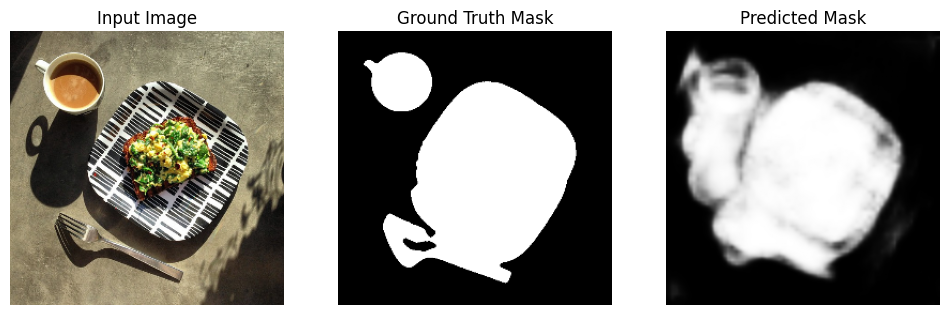

In [ ]:
# CELL-8: PREDICTION
import matplotlib.pyplot as plt

idx = 5  # change index to visualize different samples

pred = model.predict(X_val[idx:idx+1])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(X_val[idx])
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(Y_val[idx].squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
# CELL-9: SAVE OUTPUT
output_path = os.path.join(OUTPUT_SAVE_PATH, "sample_prediction.png")
plt.imsave(output_path, pred.squeeze(), cmap="gray")

print("Prediction saved at:", output_path)


Prediction saved at: /content/drive/MyDrive/infosys_internship/ASSIGNMENT -03/output/sample_prediction.png
